# 06 · PCA

The first thing to do with a table of 38 numbers per cell is to ask what its **largest
sources of variation** are — before clustering it, before embedding it, before believing
anything about it.

Principal component analysis answers that literally: it finds the directions along which
the cells vary most, in order. What makes it worth doing first is not the plot, it is
that every component can be read back to the markers that build it.

| | |
|---|---|
| **1** | Fit the PCA |
| **2** | How much does each component explain? |
| **3** | Colour it by what you already know |
| **4** | What is PC1 made of? |
| **5** | Save the components |

:::{note}
**No scaling step here, and no sampling.** Stage 1 already did the first —
[Step 19](../1_preparation/03_normalisation.ipynb) put every value in control-cell SD
units — and the second is not needed:
[chapter 04](../1_preparation/04_subsetting_and_sketching.ipynb) cut the data to the two
control conditions, which is small enough to use **every cell of**. This chapter opens
that file and starts.
:::

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_controls.h5ad"))
names = cells.var_names.tolist()
timepoint = cells.obs.timepoint_h.astype(int).values
condition = cells.obs.condition.astype(str).values

print(f"{cells.n_obs:,} cells x {cells.n_vars} markers")
print(f"  conditions: {sorted(cells.obs.condition.astype(str).unique())}")
print(f"  wells: {cells.obs.well.nunique()}   units: {cells.uns['provenance']['units']}")

9,698 cells x 38 markers
  conditions: ['DMSO', 'PBS']
  wells: 32   units: control-cell standard deviations


## 1 · Fit the PCA

`matrix` is what goes in: one row per cell, one column per marker, already centred and
scaled. Twenty components is far more than this data can support — the point of asking
for them is to see where they stop being worth anything.

In [2]:
matrix = np.asarray(cells.X)
pca = PCA(n_components=20, random_state=0).fit(matrix)
coords = pca.transform(matrix)
print(f"  {matrix.shape[0]:,} cells x {matrix.shape[1]} markers -> {coords.shape[1]} components")

  9,698 cells x 38 markers -> 20 components


## 2 · How much does each component explain?

  PC1 47.1%   PC1-2 54.3%   PC1-5 70.0%   PC1-10 81.6%


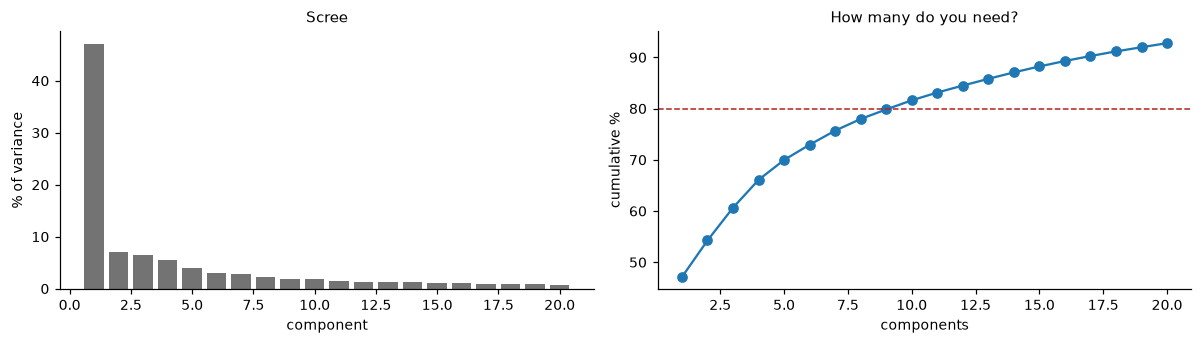

In [3]:
variance = pd.Series(pca.explained_variance_ratio_, index=range(1, 21), name="share")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(variance.index, 100 * variance.values, color="0.45")
axes[0].set(xlabel="component", ylabel="% of variance", title="Scree")
axes[1].plot(variance.index, 100 * variance.cumsum().values, marker="o")
axes[1].axhline(80, color="firebrick", ls="--", lw=1)
axes[1].set(xlabel="components", ylabel="cumulative %", title="How many do you need?")
fig.tight_layout()

print(f"  PC1 {100*variance.iloc[0]:.1f}%   PC1-2 {100*variance[:2].sum():.1f}%   "
      f"PC1-5 {100*variance[:5].sum():.1f}%   PC1-10 {100*variance[:10].sum():.1f}%")

## 3 · Colour it by what you already know

A component is only interesting once you know what it distinguishes. Colour the same
points three ways.

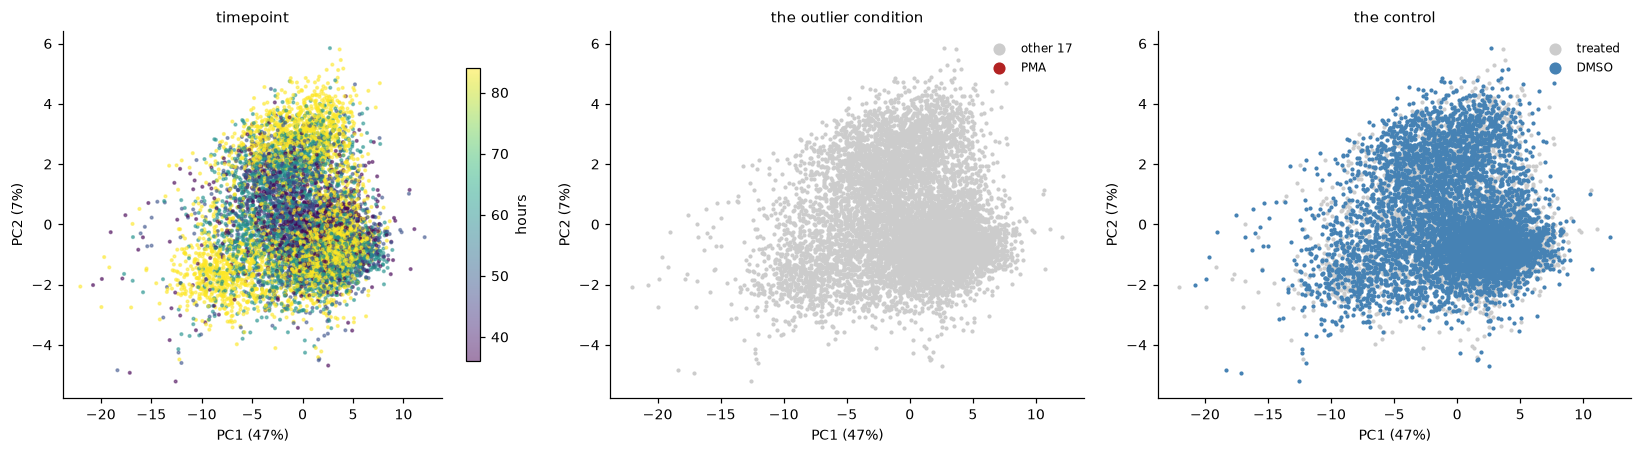

In [4]:
rng = np.random.default_rng(0)
show = rng.choice(len(coords), size=min(12_000, len(coords)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sc_ = axes[0].scatter(coords[show, 0], coords[show, 1], c=timepoint[show],
                      cmap="viridis", s=3, alpha=0.5)
axes[0].set_title("timepoint"); fig.colorbar(sc_, ax=axes[0], shrink=0.8, label="hours")

is_pma = condition == "Phorbol 12-myristate 13-acetate (PMA)"
axes[1].scatter(coords[show][~is_pma[show], 0], coords[show][~is_pma[show], 1],
                c="0.8", s=3, label="other 17")
axes[1].scatter(coords[show][is_pma[show], 0], coords[show][is_pma[show], 1],
                c="firebrick", s=3, label="PMA")
axes[1].set_title("the outlier condition"); axes[1].legend(markerscale=4, fontsize=8)

is_dmso = condition == "DMSO"
axes[2].scatter(coords[show][~is_dmso[show], 0], coords[show][~is_dmso[show], 1],
                c="0.8", s=3, label="treated")
axes[2].scatter(coords[show][is_dmso[show], 0], coords[show][is_dmso[show], 1],
                c="steelblue", s=3, label="DMSO")
axes[2].set_title("the control"); axes[2].legend(markerscale=4, fontsize=8)
for ax in axes:
    ax.set(xlabel=f"PC1 ({100*variance.iloc[0]:.0f}%)", ylabel=f"PC2 ({100*variance.iloc[1]:.0f}%)")
fig.tight_layout()

:::{important}
**This is a diagnostic, not a result.** Three questions to ask of it, in order:

1. **Is the strongest separation the timepoint?** If so, PC1 is a clock, and any
   clustering built on it will return timepoints wearing the costume of cell types.
2. **Does one condition sit on its own?** An outlier can capture a whole component to
   itself — which is why [Step 16](../1_preparation/03_normalisation.ipynb) looked for
   one before you got here.
3. **Do the controls sit in the middle?** They should. Controls at one edge means the
   normalisation did not do what you think it did.

What each of these *means* for the experiment is a question for the analysis, not for
the method. Answer them for your own subset before you plot anything else.
:::

## 4 · What is PC1 made of?

The loadings say which markers build each component. This is the step that turns "PC1"
into a sentence you can say out loud.

In [5]:
loadings = pd.DataFrame(pca.components_[:3].T, index=names, columns=["PC1", "PC2", "PC3"])
loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).head(12).round(2)

,PC1,PC2,PC3
LAMP1,0.22,-0.03,-0.05
GM130,0.21,-0.02,0.00
LAMA4,0.21,-0.03,-0.01
Pmp70,0.21,0.12,0.07
Giantin,0.20,0.10,-0.03
a-Tubulin,0.20,0.03,-0.04
GRP78,0.20,-0.03,-0.03
EEA1,0.20,-0.01,-0.04
c-Myc,0.19,0.05,0.07
Foxo3a,0.19,-0.12,-0.17


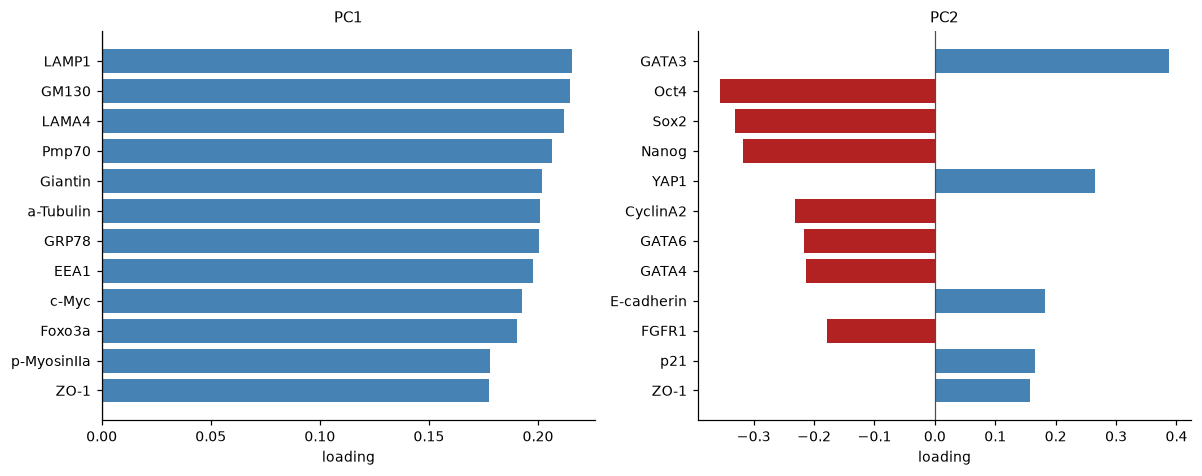

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index).head(12)[::-1]
    ax.barh(range(len(top)), top.values,
            color=["steelblue" if v > 0 else "firebrick" for v in top.values])
    ax.set(yticks=range(len(top)), yticklabels=top.index, xlabel="loading", title=pc)
    ax.axvline(0, color="0.3", lw=0.8)
fig.tight_layout()

Usually a component is a **contrast** — some markers up, others down — and you read the
two ends against each other.

**PC1 here is not.** Every loading is positive, and the largest are all about the same
size. That is the signature of a *magnitude* axis: it is not separating one biology from
another, it is separating cells with more signal from cells with less.

That is a guess from the shape of the bars. Check it directly against things PC1 was
never given — the average marker level, the counterstain, cell size, and time:

In [7]:
pd.DataFrame({
    "Spearman vs PC1": {
        "mean of all 38 markers": stats.spearmanr(coords[:, 0], matrix.mean(axis=1)).statistic,
        "DAPI":                   stats.spearmanr(coords[:, 0], cells.obs.dapi).statistic,
        "cell area":              stats.spearmanr(coords[:, 0], cells.obs.area).statistic,
        "timepoint":              stats.spearmanr(coords[:, 0], timepoint).statistic,
    }
}).round(3)

,Spearman vs PC1
mean of all 38 markers,0.993
DAPI,0.650
cell area,-0.569
timepoint,0.034


:::{important}
**PC1 is overall brightness.** It tracks the mean of all 38 markers at ρ ≈ 1.0 — it is
barely a summary, it is that average with extra steps. It rises with DAPI and falls with
cell area, so the cells at its high end are the smaller, more densely stained ones. And
it is essentially uncorrelated with timepoint, so it is not a clock either.

**A third of the variance in this dataset is spent on how bright a cell is** — read the
exact share off the scree plot above. That is normal for imaging data and it is not
useless: brightness reflects real things like nuclear density and cell state. But it is
not a phenotype contrast, and a plot of PC1 against PC2 is mostly a plot of brightness
against one real axis.

Three responses, all legitimate as long as you pick one out loud:

- **Accept it** and read PC2 onward as the structure of interest.
- **Regress it out** before clustering, if you believe it is technical.
- **Normalise per cell** (divide each cell by its own total signal) so magnitude cannot
  dominate — the imaging equivalent of library-size normalisation.

This course takes the first: PC1 is named, and the clustering in
[chapter 08](08_cell_type_annotation.ipynb) works on markers already scaled within
timepoint, so no single magnitude axis runs the result.
:::

:::{admonition} Is this a property of the controls, or of the data?
:class: dropdown

A fair worry: these are 32 untreated wells, and a first component that eats half the
variance might be something peculiar to them.

It is not. Run the same PCA on `mcs2026_clean.h5ad` — all eighteen conditions, 653,000
cells — and PC1 takes **44.5%** against the share printed above, correlating with the
mean of all markers at 0.996 and with DAPI at +0.66. Almost the same numbers.

That is the useful reading: **brightness dominates untreated cells exactly as it dominates
the whole plate**, so it is a property of imaging rather than of anything the compounds
did. Which is the general shape of what the controls are for — a finding that survives
from here to the full dataset is a finding about the measurement.
:::

## 5 · Save the components

Chapters 07 to 10 all build on this same PCA — a neighbour graph, a UMAP, a PAGA graph and
a diffusion map are computed *from* it rather than from the raw markers. Store it once.

`obsm` is the slot for per-cell matrices: same number of rows as the object, any number
of columns. It travels with the cells through every later subset.

In [8]:
cells.obsm["X_pca"] = coords
cells.uns["pca"] = {
    "variance_ratio": pca.explained_variance_ratio_,
    "n_components": int(coords.shape[1]),
    "features": "the 38 normalised markers",
}
cells.write_h5ad(H5AD_SLIM.with_name("mcs2026_controls.h5ad"), compression="gzip")
cells

AnnData object with n_obs × n_vars = 9698 × 38
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column', 'is_outlier_condition', 'replicate', 'area', 'dapi'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme', 'column'
    uns: 'provenance', 'subset_conditions', 'subset_of', 'subset_reason', 'pca'
    obsm: 'X_pca'
    layers: 'raw'

---

## Exercises

### 1. Is PC1 a clock?

Correlate PC1 with timepoint, and with a marker you would expect to track differentiation.
How much of PC1 is time?

:::{admonition} Solution
:class: dropdown

```python
from scipy import stats
print("PC1 vs timepoint:", stats.spearmanr(coords[:, 0], timepoint).statistic.round(3))
for m in ["Oct4", "SOX17", "Ki67"]:
    print(f"PC1 vs {m}:", stats.spearmanr(coords[:, 0], cells[:, m].X.ravel()).statistic.round(3))
```

If PC1 correlates strongly with time, say so in your figure captions rather than calling
it a phenotype axis. Time is a real biological variable here — the cells are
differentiating — so a time-dominated PC1 is not a bug. It only becomes one when it is
reported as something else.
:::

### 2. What happens with all 2,587 features?

Re-run the PCA on `mcs2026_qc.h5ad` — every surviving column instead of the 38 markers.
How much variance does PC1 take, and what loads on it?

:::{admonition} Solution
:class: dropdown

Texture columns outnumber intensity columns roughly seven to one, so the components come
out describing texture — and because texture features within one marker are highly
correlated with each other, a single marker's texture block can dominate a component.

More features is not more information. Choosing an interpretable subset is a decision
about *what question you are asking*, and it belongs in the notebook, not in a default.
:::

### 3. Does PMA need removing?

Fit the PCA again with PMA cells excluded. Does the variance explained by PC1 change?
Does PC2 start describing something new?

:::{admonition} Solution
:class: dropdown

```python
keep = ~is_pma
alt = PCA(n_components=10, random_state=0).fit(matrix[keep])
print("with PMA   :", pca.explained_variance_ratio_[:4].round(3))
print("without PMA:", alt.explained_variance_ratio_[:4].round(3))
```

Whether to exclude it depends on the question. Keep PMA when you want to know how far a
strong perturbation can push these cells; drop it when you want to resolve structure
among the other seventeen. Both are defensible — doing it without noticing is not.
:::

---

**Next:** [07 · UMAP](07_umap.ipynb).